# Wireline-Log Rock Mechanics & Brittleness

Read wireline logs from a **single well folder** and compute the quantities needed for
geomechanical characterization:

| Quantity | Symbol | Source curve(s) |
|---|---|---|
| Bulk density | `RHOB` | `RHOB` / `DEN` / `HDEN` (g/cc) |
| Compressional slowness | `DTC` | `DTC` / `DT` / `DTCO` (us/ft) |
| Shear slowness | `DTS` | `DTS` / `DTSX` / `DTSY` (us/ft) |
| Dynamic Young's modulus | `E` | derived from `RHOB`, `DTC`, `DTS` |
| Dynamic Poisson's ratio | `nu` | derived from `DTC`, `DTS` |
| Brittleness index | `BI` | Rickman et al. (2008), from `E` and `nu` |
| Wellbore trajectory | `TVD`, `INC` | directional survey (MD / inclination / azimuth) |

**Wellbore orientation.** `E`, `nu`, `BI` are *point rock properties* and do **not** depend on
whether the hole is vertical or horizontal. Orientation matters for the **depth reference**:
logs are recorded vs measured depth (MD), but in a deviated/horizontal well MD differs from
true vertical depth (TVD). Section 4 reads the directional survey, maps MD→TVD, flags the
vertical/build/horizontal sections, and plots the trajectory. If no survey is found the well
is treated as vertical (TVD = MD).

**Requires** `numpy`, `matplotlib`, [`lasio`](https://lasio.readthedocs.io) for LAS I/O, and
(only for an Excel survey) `pandas` + `openpyxl`. Install: `pip install lasio pandas openpyxl`.

> **Caveat: dynamic vs. static moduli.** Sonic logs give *dynamic* moduli. Geomechanical
> models (e.g. GEOS inputs) usually need *static* moduli, which are lower; apply a
> dynamic-to-static correction if you feed these into a simulator. See the last section.

**Reference:** Rickman, R., Mullen, M., Petre, E., Grieser, B., Kundert, D. (2008).
*A Practical Use of Shale Petrophysics for Stimulation Design Optimization*, SPE 115258.


In [1]:
import os, glob, warnings
import numpy as np
import matplotlib.pyplot as plt
import lasio
try:
    from dlisio import dlis
except Exception:
    dlis = None


In [2]:
# Candidate curve mnemonics, in priority order. The loader picks the first one it
# finds, searching every .las AND .dlis file in the folder. Add aliases here for new wells.

CURVE_ALIASES = {
    "RHOB": ["RHOB", "DEN", "HDEN", "RHOZ", "HRHO", "RHOM"],    # bulk density, g/cc
    "DTC":  ["DTC", "DTCO", "DTP", "DT", "DTCM", "DTC_SMOOTH"], # compressional slowness, us/ft
    "DTSX": ["DTSX", "DTS", "DTSM", "DTSH", "DTS_XX_SMOOTH"],   # shear slowness (fast/XX), us/ft
    "DTSY": ["DTSY", "DTS_YY_SMOOTH"],                          # shear slowness (slow/YY), us/ft
    # --- hole-quality QC curves (optional; used in Section 2b to reject bad-hole density) ---
    "DCOR": ["DCOR", "DRHO", "HDRA", "ZCOR", "ZCORR"],          # density correction, g/cc
    "CALI": ["CALI", "CAL", "HCAL", "DO48", "DO26", "LCAL"],    # caliper diameter, in
    "BS":   ["BS", "BIT", "BITS", "BSZ"],                       # bit size, in
}

# Rickman et al. (2008) brittleness normalization endpoints (fixed, published values).
E_MIN_MPSI, E_MAX_MPSI = 1.0, 8.0     # Young's modulus 1 -> 8 Mpsi maps 0 -> 100 %
NU_MAX, NU_MIN         = 0.40, 0.15   # Poisson's ratio 0.40 -> 0.15 maps 0 -> 100 %

# Directional survey (MD / inclination / azimuth [/ TVD]). None = auto-search the well
# folder and a sibling "Directional Survey" folder for an .xlsx/.csv/.las survey.
SURVEY_FILE = None
HORIZONTAL_INC = 85.0   # inclination (deg) at/above which the well is "horizontal"
VERTICAL_INC   = 30.0   # inclination (deg) at/below which the well is "vertical"

# Optional depth window (in the LAS depth units, here feet). None = full range.
DEPTH_MIN, DEPTH_MAX = None, None

# Unit conversions
FT_TO_M   = 0.3048
GCC_TO_KG = 1000.0            # g/cc -> kg/m^3
PA_TO_MPSI = 1.0 / 6.894757e9 # Pa -> 10^6 psi
PA_TO_GPA  = 1.0e-9

## Help functions

In [3]:
def curve_from_file(path, aliases):
    """Return (depth, values, mnem_used) for the first matching alias in this LAS file,
    or None. Uses lasio (NULLs already NaN); depth is las.index."""
    las = lasio.read(path)
    by_mnem = {c.mnemonic.upper(): c for c in las.curves}
    depth = np.asarray(las.index, dtype=float)
    for a in aliases:
        c = by_mnem.get(a.upper())
        if c is not None:
            return depth, np.asarray(c.data, dtype=float), c.mnemonic
    return None

In [4]:
def resample(depth_src, val_src, depth_ref):
    """Linear-interp val_src(depth_src) onto depth_ref, NaN outside coverage / at gaps."""
    good = np.isfinite(depth_src) & np.isfinite(val_src)
    if good.sum() < 2:
        return np.full_like(depth_ref, np.nan)
    ds, vs = depth_src[good], val_src[good]
    order = np.argsort(ds)
    ds, vs = ds[order], vs[order]
    return np.interp(depth_ref, ds, vs, left=np.nan, right=np.nan)

In [5]:
# DLIS helpers --------------------------------------------------------------
DEPTH_NAMES = {"DEPTH", "DEPT", "TDEP", "MD", "TVD"}   # DLIS index-channel mnemonics
DLIS_ABSENT = -999.0                                   # mask values <= this (DLIS -999.25 nulls)

def _mask_absent(a):
    a = np.asarray(a, dtype=float)
    a[a <= DLIS_ABSENT] = np.nan
    return a

def _dlis_frame_depth(fr):
    """Depth array (the frame's index channel) for a dlisio frame."""
    for c in fr.channels:
        if c.name.upper() in DEPTH_NAMES:
            return np.asarray(c.curves(), dtype=float)
    return np.asarray(fr.channels[0].curves(), dtype=float)   # fall back to first channel

def index_las(path):
    """{MNEM_UPPER: (depth, values)} for every curve in a LAS file."""
    las = lasio.read(path)
    depth = np.asarray(las.index, dtype=float)
    return {c.mnemonic.upper(): (depth, np.asarray(c.data, dtype=float)) for c in las.curves}

def index_dlis(path, wanted):
    """{MNEM_UPPER: (depth, values)} for 1-D channels whose name is in `wanted` (a set of
    upper-case mnemonics). Only the requested channels are read."""
    if dlis is None:
        raise RuntimeError("dlisio is not installed but a DLIS file must be read "
                           "(pip install dlisio).")
    out = {}
    with dlis.load(path) as batch:
        for lf in batch:
            for c in lf.channels:
                nm = c.name.upper()
                if nm not in wanted or nm in out:
                    continue
                try:
                    val = np.asarray(c.curves(), dtype=float)
                except Exception:
                    continue
                if val.ndim != 1:                       # skip image/array channels
                    continue
                out[nm] = (_mask_absent(_dlis_frame_depth(c.frame)), _mask_absent(val))
    return out

# Loader --------------------------------------------------------------------
def load_well_curves(folder, aliases=CURVE_ALIASES):
    las_files  = sorted(glob.glob(os.path.join(folder, "*.las")) +
                        glob.glob(os.path.join(folder, "*.LAS")))
    dlis_files = sorted(glob.glob(os.path.join(folder, "*.dlis")) +
                        glob.glob(os.path.join(folder, "*.DLIS")))
    if not las_files and not dlis_files:
        raise FileNotFoundError(f"No .las or .dlis files in {folder}")

    # 1) Index every LAS curve. LAS is preferred over DLIS when both carry a curve.
    avail = {}        # MNEM_UPPER -> (depth, values, source_file)
    for path in las_files:
        try:
            for mnem, dv in index_las(path).items():
                avail.setdefault(mnem, (dv[0], dv[1], os.path.basename(path)))
        except Exception as e:
            print(f"  ! skip {os.path.basename(path)}: {e}")

    def alias_hit(al):                       # highest-priority alias present in `avail`
        for a in al:
            if a.upper() in avail:
                return a.upper()
        return None

    # 2) Only crack open DLIS files if some target is still unsatisfied (keeps
    #    LAS-only wells fast and their behaviour unchanged).
    missing = {t: al for t, al in aliases.items() if alias_hit(al) is None}
    if missing and dlis_files:
        wanted = {a.upper() for al in missing.values() for a in al}
        for path in dlis_files:
            if not wanted:
                break
            try:
                got = index_dlis(path, wanted)
            except Exception as e:
                print(f"  ! skip {os.path.basename(path)}: {e}")
                continue
            for mnem, (d, v) in got.items():
                avail.setdefault(mnem, (d, v, os.path.basename(path)))
            wanted -= set(got)               # stop searching for curves already located

    # 3) Resolve each target to its highest-priority available alias.
    found = {}        # target -> (depth, values, source_file, mnem_used)
    for t, al in aliases.items():
        m = alias_hit(al)
        if m is not None:
            d, v, src = avail[m]
            found[t] = (d, v, src, m)

    print(f"Scanned {len(las_files)} LAS + {len(dlis_files)} DLIS file(s). Curves located:")
    for t in aliases:
        if t in found:
            _, _, src, mnem = found[t]
            print(f"  {t:5s} <- {mnem:13s} ({src})")
        else:
            print(f"  {t:5s} <- NOT FOUND")

    if "RHOB" not in found:
        raise RuntimeError("Density (RHOB/DEN) not found in any LAS/DLIS file.")

    # Reference depth grid = density curve's depth (finite, unique).
    d_ref = found["RHOB"][0]
    d_ref = np.unique(d_ref[np.isfinite(d_ref)])

    curves = {"DEPTH": d_ref}
    for t, (depth, val, _, _) in found.items():
        curves[t] = resample(depth, val, d_ref)
    return curves, found


In [6]:
def find_survey(folder):
    """Find a directional/deviation survey file near the well folder, or return None.
    Searches the well folder and its parent's survey sub-folders ('Directional Survey',
    'Deviation Survey', ...) and only accepts files that actually look like a survey, so a
    wireline-log .las is never mistaken for one."""
    well_root = os.path.dirname(folder.rstrip("/"))
    dirs = [folder, well_root] + [os.path.join(well_root, n) for n in
            ("Directional Survey", "Deviation Survey", "Survey", "Surveys")]
    SURVEY_DIRS = {"directional survey", "deviation survey", "survey", "surveys"}
    KEYS = ("ds_", "_ds_", "_ds.", "survey", "deviat", "direction", "gyro")
    cands = []
    for d in dirs:
        in_survey_dir = os.path.basename(d.rstrip("/")).lower() in SURVEY_DIRS
        for ext in ("*.xlsx", "*.xlsm", "*.xls", "*.csv", "*.las"):
            for p in glob.glob(os.path.join(d, ext)):
                n = os.path.basename(p).lower()
                if "rock_props" in n:                      # our own export, skip
                    continue
                # accept only genuine surveys: inside a survey folder, or the name says so.
                if in_survey_dir or any(k in n for k in KEYS):
                    cands.append(p)
    if not cands:
        return None
    def rank(p):                                           # prefer processed DS spreadsheets
        n = os.path.basename(p).lower()
        return (("processed" in n or "ds_final" in n),
                ("ds_" in n or "_ds" in n),
                not n.endswith(".las"))
    return sorted(set(cands), key=rank, reverse=True)[0]

In [7]:
def _colmap(names):
    """Map fuzzy / abbreviated survey header names -> column index for the fields we need
    (handles both 'Measured Depth'/'Inclination'/'Azimuth' and short 'MD'/'INC'/'AZI')."""
    low = [str(n).strip().lower() for n in names]
    def find(*keys):
        for j, n in enumerate(low):
            if any(k in n for k in keys):
                return j
        return None
    return dict(md=find("measured depth", "md", "depth"),
                inc=find("inclination", "incl", "inc", "dev"),
                azi=find("azimuth", "azi"),
                tvd=find("true vertical depth", "tvd"),
                vs=find("vertical section", "vsec", "v.sect"))

In [8]:
def read_survey(path):
    """Return md, inc, azi, tvd(optional), vs(optional) as float arrays (NaN-filtered).
    The header row is auto-detected as the first row mapping to at least MD + INC + one of
    AZI/TVD, which tolerates the long metadata blocks and abbreviated headers used by the
    different survey vendors (.xlsx / .xlsm / .csv / .las)."""
    import pandas as pd
    if path.lower().endswith((".xlsx", ".xlsm", ".xls")):
        raw = pd.read_excel(path, header=None)
    elif path.lower().endswith(".csv"):
        raw = pd.read_csv(path, header=None, engine="python")
    else:  # a LAS survey
        las = lasio.read(path)
        raw = pd.DataFrame(las.data, columns=[c.mnemonic for c in las.curves])
        raw = pd.concat([pd.DataFrame([raw.columns.tolist()], columns=raw.columns), raw],
                        ignore_index=True)
    # locate the header row: first row that maps to MD + INC + (AZI or TVD)
    hdr = None
    for i in range(min(120, len(raw))):
        cm = _colmap(raw.iloc[i].tolist())
        if (cm["md"] is not None and cm["inc"] is not None and
                (cm["azi"] is not None or cm["tvd"] is not None)):
            hdr = i
            break
    if hdr is None:
        raise ValueError(f"Could not locate a survey header row in {os.path.basename(path)}")
    cm = _colmap(raw.iloc[hdr].tolist())
    body = raw.iloc[hdr + 1:]
    def col(key):
        j = cm[key]
        if j is None:
            return None
        return np.asarray(pd.to_numeric(body.iloc[:, j], errors="coerce"))
    md, inc = col("md"), col("inc")
    azi = col("azi"); azi = np.zeros_like(md) if azi is None else azi
    tvd, vs = col("tvd"), col("vs")
    good = np.isfinite(md) & np.isfinite(inc)
    order = np.argsort(md[good])
    sel = np.where(good)[0][order]
    def take(a): return None if a is None else a[sel]
    return md[sel], inc[sel], np.nan_to_num(azi[sel]), take(tvd), take(vs)

In [9]:
def minimum_curvature(md, inc_deg, azi_deg):
    """Minimum-curvature TVD, North, East, horizontal-displacement from a survey."""
    I, A = np.radians(inc_deg), np.radians(azi_deg)
    tvd = np.zeros_like(md); north = np.zeros_like(md); east = np.zeros_like(md)
    for k in range(1, len(md)):
        dMD = md[k] - md[k-1]
        cosb = (np.cos(I[k]-I[k-1])
                - np.sin(I[k-1])*np.sin(I[k])*(1.0 - np.cos(A[k]-A[k-1])))
        beta = np.arccos(np.clip(cosb, -1.0, 1.0))
        rf = 1.0 if beta < 1e-9 else (2.0/beta)*np.tan(beta/2.0)
        tvd[k]   = tvd[k-1]   + dMD/2*(np.cos(I[k-1])      + np.cos(I[k]))      * rf
        north[k] = north[k-1] + dMD/2*(np.sin(I[k-1])*np.cos(A[k-1]) + np.sin(I[k])*np.cos(A[k])) * rf
        east[k]  = east[k-1]  + dMD/2*(np.sin(I[k-1])*np.sin(A[k-1]) + np.sin(I[k])*np.sin(A[k]))  * rf
    return tvd, north, east, np.hypot(north, east)

## 1. Configuration

Point `WELL_FOLDER` at the well's log folder. Everything else is mnemonic aliases
(so the notebook works across wells/vendors) and the Rickman brittleness endpoints.


In [10]:
DATA_ROOT = "../inputs/field_data/well_data"   # packaged wireline subset (relative to notebooks/)

WELLS = {
    "b1h": None,
    "b2h": f"{DATA_ROOT}/boxwood-2h-test-well/Wireline Logs",
    "b3h": f"{DATA_ROOT}/boxwood-3h-test-well/Wireline Logs",
    "b4h": f"{DATA_ROOT}/boxwood-4h-test-well/Wireline Logs",
    "b5ph": f"{DATA_ROOT}/boxwood-5ph-vertical-obs-well/Wireline Logs",
    "b6s": f"{DATA_ROOT}/boxwood-6s-slant-core-well/Wireline Logs"
}

In [11]:
WELL_FOLDER = WELLS["b6s"]
SAVE_PARENT_FOLDER = "../inputs/field_data/well_logs"   # writes B6S products where compute_stress_profile reads them
WELL_NAME = WELL_FOLDER.split("boxwood-")[-1].split("-")[0]
WELL_NAME = f"B{WELL_NAME.upper()}"




print(f"Running brittleness analysis for well {WELL_NAME} in folder {WELL_FOLDER}")

Running brittleness analysis for well B6S in folder ../inputs/field_data/well_data/boxwood-6s-slant-core-well/Wireline Logs


## 2. Load & merge curves across the folder


In [12]:
curves, found = load_well_curves(WELL_FOLDER)

# Optional depth crop
depth = curves["DEPTH"]
mask = np.ones_like(depth, dtype=bool)
if DEPTH_MIN is not None: mask &= depth >= DEPTH_MIN
if DEPTH_MAX is not None: mask &= depth <= DEPTH_MAX
for k in curves:
    curves[k] = curves[k][mask]
depth = curves["DEPTH"]
print(f"\nDepth grid: {depth.min():.1f} - {depth.max():.1f} ft, {depth.size} samples")


Scanned 5 LAS + 0 DLIS file(s). Curves located:
  RHOB  <- DEN           (42301343810000_CXD_MAIN_R1_ANISOTROPIC_ROCK_MECHANICAL_PROPERTIES.las)
  DTC   <- DTC_SMOOTH    (42301343810000_CXD_MAIN_R1_ANISOTROPIC_ROCK_MECHANICAL_PROPERTIES.las)
  DTSX  <- DTS_XX_SMOOTH (42301343810000_CXD_MAIN_R1_DUAL_SHEAR_SEMBLANCE.las)
  DTSY  <- DTS_YY_SMOOTH (42301343810000_CXD_MAIN_R1_DUAL_SHEAR_SEMBLANCE.las)
  DCOR  <- DCOR          (42301343810000_CXD_MAIN_R1_ANISOTROPIC_ROCK_MECHANICAL_PROPERTIES.las)
  CALI  <- DO48          (42301343810000_CXD_MAIN_R1_ANISOTROPIC_ROCK_MECHANICAL_PROPERTIES.las)
  BS    <- BIT           (42301343810000_CXD_MAIN_R1_ANISOTROPIC_ROCK_MECHANICAL_PROPERTIES.las)

Depth grid: 11337.9 - 14141.0 ft, 8545 samples


## 2b. Hole-quality QC (bad-hole density rejection)

Density (`RHOB`) is the only log here that needs good borehole contact. In washed-out or
rugose hole the pad lifts off and the reading reads too low, biasing Young's modulus `E` and
the brittleness index. This step flags bad-hole intervals from the **density correction**
(`DCOR`) and the **caliper − bit-size** gap, and blanks (`NaN`) the density there so those
samples drop out of `E`/`BI`. Sonic-derived `nu` (a velocity ratio) is unaffected.
Tune `DCOR_MAX` / `CALI_OVER_BIT`, or set `USE_HOLE_QC = False` to disable.

In [13]:
# Washed-out / rugose borehole corrupts the density measurement (the source-detector pad
# loses contact), which then propagates into E and the brittleness index. Flag bad-hole
# intervals from the density correction and the caliper-minus-bit gap
USE_HOLE_QC   = True     # set False to keep all density samples
DCOR_MAX      = 0.10     # |density correction| (g/cc) above this         -> bad hole
CALI_OVER_BIT = 1.0      # caliper exceeds bit size by more than this (in) -> bad hole

bad, reasons = np.zeros(depth.shape, dtype=bool), []
if USE_HOLE_QC:
    dcor = curves.get("DCOR")
    if dcor is not None:
        bad |= np.abs(dcor) > DCOR_MAX                 # NaN comparisons -> False (sample kept)
        reasons.append(f"|DCOR| > {DCOR_MAX} g/cc")
    cali, bs = curves.get("CALI"), curves.get("BS")
    if cali is not None and bs is not None:
        bad |= (cali - bs) > CALI_OVER_BIT
        reasons.append(f"(caliper - bit) > {CALI_OVER_BIT} in")

n_before = int(np.isfinite(curves["RHOB"]).sum())
if reasons:
    curves["RHOB"] = np.where(bad, np.nan, curves["RHOB"])
    n_blanked = n_before - int(np.isfinite(curves["RHOB"]).sum())
    print(f"Hole-quality QC [{' or '.join(reasons)}]: blanked {n_blanked} of {n_before} "
          f"density samples ({100 * n_blanked / max(n_before, 1):.1f}%) in bad hole.")
else:
    print("Hole-quality QC: no DCOR/caliper curves found (or disabled) - density unchanged.")


Hole-quality QC [|DCOR| > 0.1 g/cc or (caliper - bit) > 1.0 in]: blanked 225 of 7029 density samples (3.2%) in bad hole.


## 3. Wellbore trajectory & orientation (deviation survey)


In [14]:
SURVEY_FILE = SURVEY_FILE or find_survey(WELL_FOLDER)
has_survey = bool(SURVEY_FILE) and os.path.exists(SURVEY_FILE)

if has_survey:
    try:
        s_md, s_inc, s_azi, s_tvd, s_vs = read_survey(SURVEY_FILE)
    except Exception as e:
        print(f"Found {os.path.basename(SURVEY_FILE)} but could not parse it as a survey "
              f"({e}) -> treating well as VERTICAL.")
        has_survey = False

if has_survey:
    mc_tvd, mc_n, mc_e, mc_hdisp = minimum_curvature(s_md, s_inc, s_azi)
    tvd_path = s_tvd if (s_tvd is not None and np.isfinite(s_tvd).all()) else mc_tvd
    hdisp    = mc_hdisp                                   # horizontal displacement for the plot
    # map survey onto the log MD grid
    TVD = np.interp(depth, s_md, tvd_path, left=np.nan, right=np.nan)
    INC = np.interp(depth, s_md, s_inc,    left=np.nan, right=np.nan)
    print(f"Survey: {os.path.basename(SURVEY_FILE)}  ({s_md.size} stations)")
    print(f"  MD  {s_md.min():.0f}-{s_md.max():.0f} ft | TVD {np.nanmin(tvd_path):.0f}-{np.nanmax(tvd_path):.0f} ft")
    print(f"  max inclination {s_inc.max():.1f} deg -> "
          f"{'HORIZONTAL well' if s_inc.max() >= HORIZONTAL_INC else 'deviated/vertical well'}")
    print(f"  lateral (horizontal displacement) ~ {hdisp.max():.0f} ft")
else:
    print("No directional survey found -> treating well as VERTICAL (TVD = MD).")
    TVD = depth.copy(); INC = np.zeros_like(depth)
    s_md = s_inc = hdisp = tvd_path = None

# per-sample orientation flag (0 vertical, 1 build/deviated, 2 horizontal)
ORIENT = np.where(INC >= HORIZONTAL_INC, 2, np.where(INC <= VERTICAL_INC, 0, 1)).astype(float)
ORIENT[~np.isfinite(INC)] = np.nan

Survey: Gyrodata Surveys Boxwood 55-1-12 Unit 6S1.xlsm  (154 stations)
  MD  0-14160 ft | TVD 0-11893 ft
  max inclination 87.0 deg -> HORIZONTAL well
  lateral (horizontal displacement) ~ 1758 ft


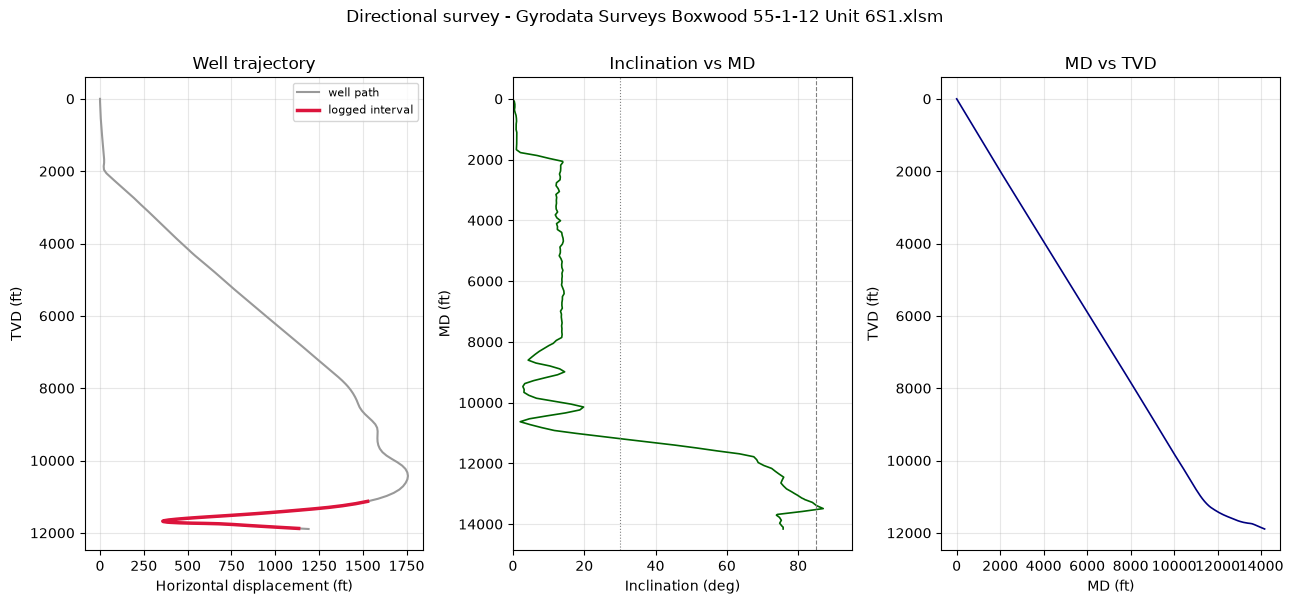

Saved survey plot to ../inputs/field_data/well_logs/B6S/b6s_survey.png


In [15]:
if has_survey:
    fig, ax = plt.subplots(1, 3, figsize=(13, 6))

    # (a) trajectory: TVD vs horizontal displacement, logged interval highlighted
    ax[0].plot(hdisp, tvd_path, "-", color="0.6", lw=1.5, label="well path")
    seg = (s_md >= depth.min()) & (s_md <= depth.max())
    ax[0].plot(hdisp[seg], tvd_path[seg], "-", color="crimson", lw=2.5, label="logged interval")
    ax[0].set_xlabel("Horizontal displacement (ft)"); ax[0].set_ylabel("TVD (ft)")
    ax[0].invert_yaxis(); ax[0].set_title("Well trajectory"); ax[0].legend(fontsize=8)

    # (b) inclination vs MD
    ax[1].plot(s_inc, s_md, "-", color="darkgreen", lw=1.2)
    ax[1].axvline(HORIZONTAL_INC, ls="--", color="gray", lw=0.8)
    ax[1].axvline(VERTICAL_INC,  ls=":",  color="gray", lw=0.8)
    ax[1].set_xlabel("Inclination (deg)"); ax[1].set_ylabel("MD (ft)")
    ax[1].invert_yaxis(); ax[1].set_title("Inclination vs MD"); ax[1].set_xlim(0, 95)

    # (c) MD vs TVD (shows the lateral as a near-vertical-TVD plateau)
    ax[2].plot(s_md, tvd_path, "-", color="navy", lw=1.2)
    ax[2].set_xlabel("MD (ft)"); ax[2].set_ylabel("TVD (ft)")
    ax[2].invert_yaxis(); ax[2].set_title("MD vs TVD")

    for a in ax: a.grid(alpha=0.3)
    fig.suptitle("Directional survey - " + os.path.basename(SURVEY_FILE), y=1.0)
    fig.tight_layout(); plt.show()
    _save_path = os.path.join(os.path.join(SAVE_PARENT_FOLDER, WELL_NAME), f"{WELL_NAME.lower()}_survey.png")
    fig.savefig(_save_path, dpi=200, bbox_inches="tight")
    print(f"Saved survey plot to {_save_path}")
else:
    print("No survey to plot.")


## 4. Rock-mechanics from sonic + density

With slowness `DT` in us/ft, velocity is `V = 1e6 / DT` ft/s. Using compressional `Vp`,
shear `Vs` (m/s) and density `rho` (kg/m^3):

- Velocity ratio: $r = V_p/V_s = DTS/DTC$
- **Poisson's ratio:** $\nu = \dfrac{r^2 - 2}{2\,(r^2 - 1)}$
- **Shear modulus:** $G = \rho\,V_s^2$
- **Young's modulus:** $E = 2\,G\,(1+\nu)$

Shear slowness is taken as the mean of the available fast/slow shear curves
(`DTSX`, `DTSY`); they differ where the formation is anisotropic.


In [16]:
rhob = curves["RHOB"]                       # g/cc
dtc  = curves.get("DTC")                    # us/ft

# Shear slowness: average whatever shear curves are present
shear_cols = [curves[k] for k in ("DTSX", "DTSY") if k in curves]
if not shear_cols:
    raise RuntimeError("No shear slowness (DTS/DTSX/DTSY) found - cannot compute nu/E.")
with warnings.catch_warnings():                   # depths with no shear -> NaN (expected)
    warnings.simplefilter("ignore", category=RuntimeWarning)
    dts = np.nanmean(np.vstack(shear_cols), axis=0)   # us/ft

# Velocities (m/s) from slowness (us/ft):  V[ft/s] = 1e6/DT ;  *0.3048 -> m/s
with np.errstate(divide="ignore", invalid="ignore"):
    vp = (1.0e6 / dtc) * FT_TO_M
    vs = (1.0e6 / dts) * FT_TO_M
    rho = rhob * GCC_TO_KG

    r2 = (vp / vs) ** 2
    nu = (r2 - 2.0) / (2.0 * (r2 - 1.0))            # dynamic Poisson's ratio
    G  = rho * vs ** 2                              # shear modulus, Pa
    E  = 2.0 * G * (1.0 + nu)                       # dynamic Young's modulus, Pa

E_GPa  = E * PA_TO_GPA
E_Mpsi = E * PA_TO_MPSI

print(f"Vp  : {np.nanmin(vp):8.0f} - {np.nanmax(vp):8.0f} m/s")
print(f"Vs  : {np.nanmin(vs):8.0f} - {np.nanmax(vs):8.0f} m/s")
print(f"nu  : {np.nanmin(nu):8.3f} - {np.nanmax(nu):8.3f}")
print(f"E   : {np.nanmin(E_GPa):8.2f} - {np.nanmax(E_GPa):8.2f} GPa "
      f"({np.nanmin(E_Mpsi):.2f} - {np.nanmax(E_Mpsi):.2f} Mpsi)")


Vp  :     3857 -     6393 m/s
Vs  :     2100 -     3105 m/s
nu  :    0.090 -    0.395
E   :    29.15 -    67.86 GPa (4.23 - 9.84 Mpsi)


## 5. Brittleness index (Rickman et al., 2008)

Each elastic property is rescaled to a 0–100 % "brittleness", then averaged. Brittle rock
has **high** Young's modulus and **low** Poisson's ratio:

$$BI_E = \frac{E - E_{min}}{E_{max} - E_{min}}\times100,\qquad
  BI_\nu = \frac{\nu - \nu_{max}}{\nu_{min} - \nu_{max}}\times100,\qquad
  BI = \tfrac{1}{2}\,(BI_E + BI_\nu)$$

with the published endpoints $E\in[1,8]$ Mpsi and $\nu\in[0.40,0.15]$ (set in the config cell).


In [17]:
BI_E  = (E_Mpsi - E_MIN_MPSI) / (E_MAX_MPSI - E_MIN_MPSI) * 100.0
BI_nu = (nu - NU_MAX) / (NU_MIN - NU_MAX) * 100.0
BI    = 0.5 * (BI_E + BI_nu)

# Clip the component/percent values to a sensible 0-100 display range (raw kept above)
BI_E_c, BI_nu_c, BI_c = (np.clip(x, 0, 100) for x in (BI_E, BI_nu, BI))

print(f"Brittleness index (Rickman 2008): "
      f"min {np.nanmin(BI):.1f}  mean {np.nanmean(BI):.1f}  max {np.nanmax(BI):.1f} %")


Brittleness index (Rickman 2008): min 37.4  mean 64.6  max 104.2 %


## 6. Results table & CSV export

Includes `TVD_ft` and `INC_deg` (from the survey) and `ORIENT` (0 = vertical, 1 = build,
2 = horizontal) so each rock-property sample carries its true depth and wellbore attitude.


In [18]:
columns = [
    ("DEPTH_MD_ft", depth),
    ("TVD_ft",   TVD),
    ("INC_deg",  INC),
    ("ORIENT",   ORIENT),
    ("RHOB_gcc", rhob),
    ("DTC_usft", dtc),
    ("DTS_usft", dts),
    ("Vp_ms",    vp),
    ("Vs_ms",    vs),
    ("PR_dyn",   nu),
    ("E_GPa",    E_GPa),
    ("E_Mpsi",   E_Mpsi),
    ("BI_E_pct", BI_E),
    ("BI_PR_pct",BI_nu),
    ("BI_pct",   BI),
]
names  = [c[0] for c in columns]
table  = np.column_stack([c[1] for c in columns])

_save_path = os.path.join(os.path.join(SAVE_PARENT_FOLDER, WELL_NAME), f"{WELL_NAME.lower()}_rock_props_brittleness.csv")
np.savetxt(_save_path, table, delimiter=",", header=",".join(names),
           comments="", fmt="%.4f")
print("Wrote", _save_path)

# Preview first rows with finite E
fin = np.where(np.isfinite(E_GPa))[0][:6]
print("  " + "  ".join(f"{n:>9s}" for n in names))
for i in fin:
    print("  " + "  ".join(f"{table[i,j]:9.3f}" for j in range(len(names))))


Wrote ../inputs/field_data/well_logs/B6S/b6s_rock_props_brittleness.csv
  DEPTH_MD_ft     TVD_ft    INC_deg     ORIENT   RHOB_gcc   DTC_usft   DTS_usft      Vp_ms      Vs_ms     PR_dyn      E_GPa     E_Mpsi   BI_E_pct  BI_PR_pct     BI_pct
  11743.048  11320.231     65.933      1.000      2.461     70.067    116.261   4350.097   2621.677      0.215     41.104      5.962     70.881     74.076     72.479
  11743.376  11320.367     65.947      1.000      2.459     69.791    116.945   4367.350   2606.349      0.223     40.872      5.928     70.399     70.630     70.514
  11743.704  11320.503     65.960      1.000      2.459     69.430    117.659   4390.030   2590.535      0.233     40.686      5.901     70.015     66.848     68.432
  11744.032  11320.639     65.974      1.000      2.460     68.993    118.295   4417.869   2576.608      0.242     40.578      5.885     69.791     63.099     66.445
  11744.360  11320.775     65.988      1.000      2.463     68.496    118.779   4449.894   2566.

## 7. Composite log plot

Tracks are plotted vs **measured depth** (the axis the tools record on). The shaded band marks
the **horizontal** section (`INC >= HORIZONTAL_INC`) so you can see which properties come from
the lateral; a horizontal well's lateral spans a large MD range at nearly constant TVD, so MD,
not TVD, is the useful axis there. Set `Y_AXIS = "TVD"` to plot vs true vertical depth instead.


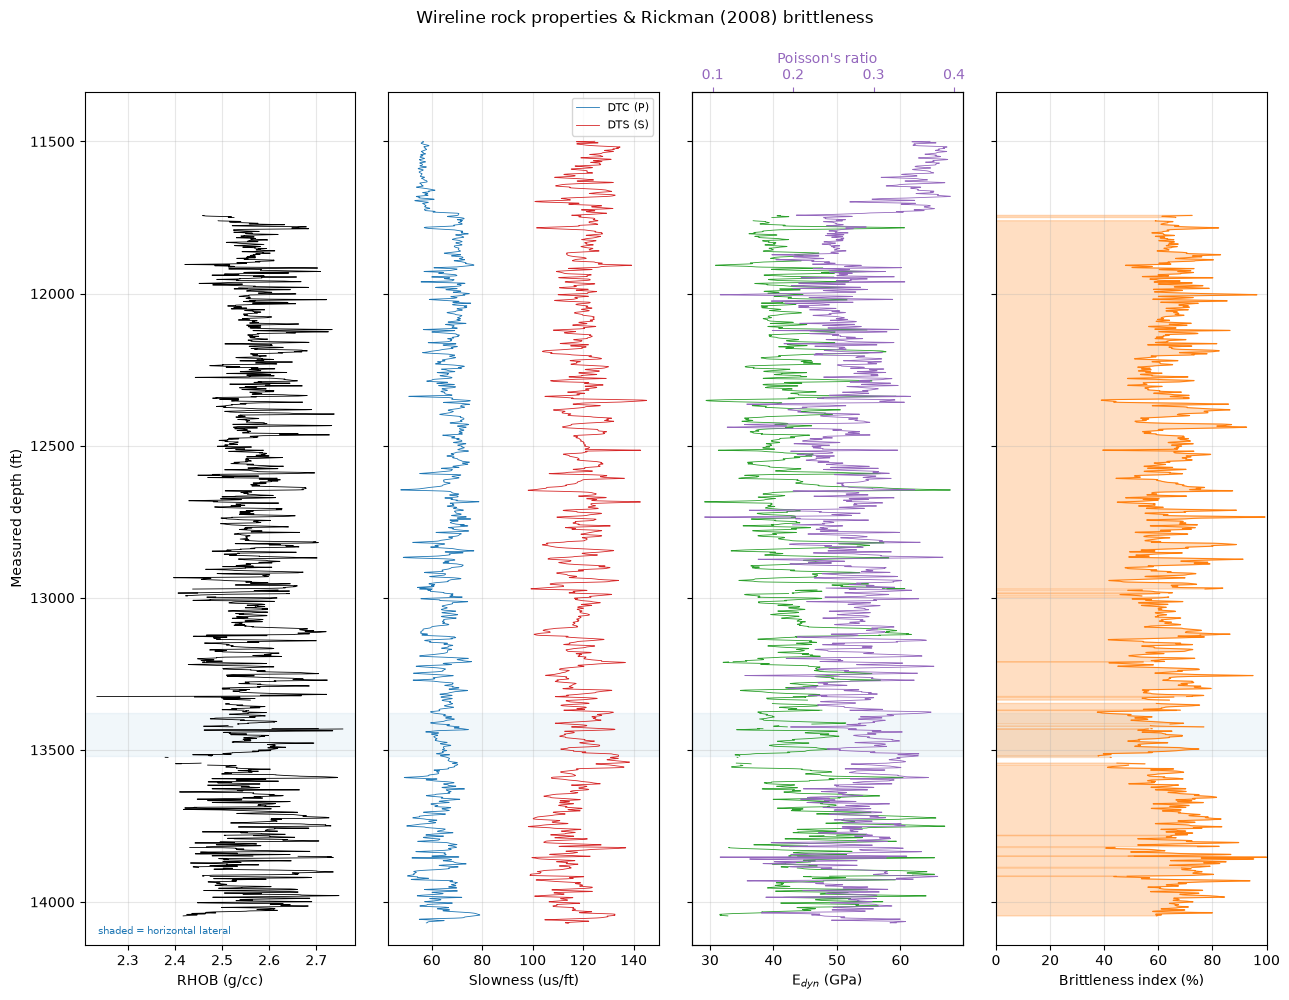

Saved rock properties plot to ../inputs/field_data/well_logs/B6S/b6s_rock_props.png


In [19]:
Y_AXIS = "MD"                       # "MD" (default) or "TVD"
ydata  = depth if Y_AXIS == "MD" else TVD
ylabel = "Measured depth (ft)" if Y_AXIS == "MD" else "TVD (ft)"

fig, axes = plt.subplots(1, 4, figsize=(13, 10), sharey=True)

ax = axes[0]
ax.plot(rhob, ydata, color="black", lw=0.6)
ax.set_xlabel("RHOB (g/cc)"); ax.set_ylabel(ylabel)

ax = axes[1]
ax.plot(dtc, ydata, color="tab:blue", lw=0.6, label="DTC (P)")
ax.plot(dts, ydata, color="tab:red",  lw=0.6, label="DTS (S)")
ax.set_xlabel("Slowness (us/ft)"); ax.legend(fontsize=8)

ax = axes[2]
ax.plot(E_GPa, ydata, color="tab:green", lw=0.6)
ax.set_xlabel("E$_{dyn}$ (GPa)")
axt = ax.twiny()
axt.plot(nu, ydata, color="tab:purple", lw=0.6)
axt.set_xlabel("Poisson's ratio", color="tab:purple")
axt.tick_params(axis="x", colors="tab:purple")

ax = axes[3]
ax.plot(BI_c, ydata, color="tab:orange", lw=0.7)
ax.fill_betweenx(ydata, 0, BI_c, color="tab:orange", alpha=0.25)
ax.set_xlabel("Brittleness index (%)"); ax.set_xlim(0, 100)

# shade the horizontal section across all tracks
if has_survey and np.nanmax(INC) >= HORIZONTAL_INC:
    horiz = INC >= HORIZONTAL_INC
    y0, y1 = np.nanmin(ydata[horiz]), np.nanmax(ydata[horiz])
    for a in axes:
        a.axhspan(y0, y1, color="tab:blue", alpha=0.06, zorder=0)
    axes[0].text(0.05, 0.01, "shaded = horizontal lateral", transform=axes[0].transAxes,
                 fontsize=7, color="tab:blue", va="bottom")

for a in axes:
    a.grid(alpha=0.3)
axes[0].set_ylim(np.nanmax(ydata), np.nanmin(ydata))   # depth increases downward
fig.suptitle("Wireline rock properties & Rickman (2008) brittleness", y=0.995)
fig.tight_layout()
_save_path = os.path.join(os.path.join(SAVE_PARENT_FOLDER, WELL_NAME), f"{WELL_NAME.lower()}_rock_props.png")
fig.savefig(_save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved rock properties plot to {_save_path}")
